<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day2_Exercises_XP_Gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXERCICE 1

In [ ]:
import pandas as pd
import zipfile
import requests
import io
from sklearn.preprocessing import StandardScaler, MinMaxScaler

url_titanic = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/titanic%20dataset.zip"

response = requests.get(url_titanic)
z = zipfile.ZipFile(io.BytesIO(response.content))
titanic_df = pd.read_csv(z.open("titanic dataset/train.csv"))
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Numerical columns :")
print(titanic_df.select_dtypes(include=['float64', 'int64']).columns.tolist())

print("\nFare stats :")
print(titanic_df["Fare"].describe())

print("\nAge stats :")
print(titanic_df["Age"].describe())

Numerical columns :
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Fare stats :
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

Age stats :
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


In [ ]:
# Handle missing Age values first
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean())

# Z-score standardization on Age (Gaussian distribution)
scaler_std = StandardScaler()
titanic_df["Age_Zscore"] = scaler_std.fit_transform(titanic_df[["Age"]])

# Min-Max normalization on Fare (skewed distribution)
scaler_mm = MinMaxScaler()
titanic_df["Fare_MinMax"] = scaler_mm.fit_transform(titanic_df[["Fare"]])

print(titanic_df[["Age", "Age_Zscore", "Fare", "Fare_MinMax"]].head(10))

print("\nAge_Zscore stats :")
print(titanic_df["Age_Zscore"].describe().round(3))

print("\nFare_MinMax stats :")
print(titanic_df["Fare_MinMax"].describe().round(3))

         Age  Age_Zscore     Fare  Fare_MinMax
0  22.000000   -0.592481   7.2500     0.014151
1  38.000000    0.638789  71.2833     0.139136
2  26.000000   -0.284663   7.9250     0.015469
3  35.000000    0.407926  53.1000     0.103644
4  35.000000    0.407926   8.0500     0.015713
5  29.699118    0.000000   8.4583     0.016510
6  54.000000    1.870059  51.8625     0.101229
7   2.000000   -2.131568  21.0750     0.041136
8  27.000000   -0.207709  11.1333     0.021731
9  14.000000   -1.208115  30.0708     0.058694

Age_Zscore stats :
count    891.000
mean       0.000
std        1.001
min       -2.253
25%       -0.592
50%        0.000
75%        0.408
max        3.871
Name: Age_Zscore, dtype: float64

Fare_MinMax stats :
count    891.000
mean       0.063
std        0.097
min        0.000
25%        0.015
50%        0.028
75%        0.061
max        1.000
Name: Fare_MinMax, dtype: float64



### Numerical Columns Identified
| Column | Mean | Std | Max | Distribution |
|---|---|---|---|---|
| Age | 29.70 | 14.53 | 80.0 | Roughly Gaussian |
| Fare | 32.20 | 49.69 | 512.33 | Highly skewed |

### Scaling Applied
| Column | Method | Reasoning |
|---|---|---|
| Age | StandardScaler (Z-score) | Gaussian distribution — mean=0, std=1 |
| Fare | MinMaxScaler | Skewed with extreme values — range [0,1] |

### Results After Scaling
| Column | Mean | Std | Min | Max |
|---|---|---|---|---|
| Age_Zscore | 0.000 | 1.001 | -2.253 | 3.871 |
| Fare_MinMax | 0.063 | 0.097 | 0.000 | 1.000 |

### Effect of Scaling
- Age_Zscore is centered at 0 with std=1 — ready for
  distance-based models like KNN or SVM.
- Fare_MinMax is bounded between 0 and 1 — extreme values
  like 512.33 are now compressed to 1.0 without distortion.
- Scaling prevents high-magnitude features from dominating
  the model over lower-magnitude ones.

EXERCICE 2

In [ ]:
# Feature 1 : FamilySize
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1

# Feature 2 : IsAlone
titanic_df["IsAlone"] = (titanic_df["FamilySize"] == 1).astype(int)

print(titanic_df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head(10))
print(f"\nIsAlone distribution :\n{titanic_df['IsAlone'].value_counts()}")

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0

IsAlone distribution :
IsAlone
1    537
0    354
Name: count, dtype: int64


In [ ]:
# Survival rate by IsAlone
print(" SURVIVAL RATE BY IsAlone ")
print(titanic_df.groupby("IsAlone")["Survived"].mean().round(3))

# Survival rate by FamilySize
print("\n SURVIVAL RATE BY FamilySize ")
print(titanic_df.groupby("FamilySize")["Survived"].mean().round(3))

 SURVIVAL RATE BY IsAlone 
IsAlone
0    0.506
1    0.304
Name: Survived, dtype: float64

 SURVIVAL RATE BY FamilySize 
FamilySize
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64



### New Features Created
| Feature | Formula | Reasoning |
|---|---|---|
| FamilySize | SibSp + Parch + 1 | Total people travelling together |
| IsAlone | 1 if FamilySize == 1 else 0 | Binary flag for solo travellers |

### IsAlone Distribution
| IsAlone | Count |
|---|---|
| 1 (alone) | 537 |
| 0 (with family) | 354 |

### Survival Rate Analysis

**By IsAlone :**
| IsAlone | Survival Rate |
|---|---|
| 0 (with family) | 50.6% |
| 1 (alone) | 30.4% |

Passengers travelling with family had a significantly
higher survival rate than solo travellers.

**By FamilySize :**
| FamilySize | Survival Rate |
|---|---|
| 1 (alone) | 30.4% |
| 2 | 55.3% |
| 3 | 57.8% |
| 4 | 72.4% |
| 5+ | decreasing to 0% |

Small families (2-4) had the highest survival rates.
Very large families (8, 11) had 0% survival rate —
likely due to difficulty evacuating together.

EXERCICE 3

In [ ]:
# Min-Max normalization
scaler_mm = MinMaxScaler()
titanic_df["Age_MinMax"] = scaler_mm.fit_transform(titanic_df[["Age"]])
titanic_df["Fare_MinMax"] = scaler_mm.fit_transform(titanic_df[["Fare"]])

# Z-score normalization
scaler_std = StandardScaler()
titanic_df["Age_Zscore"] = scaler_std.fit_transform(titanic_df[["Age"]])
titanic_df["Fare_Zscore"] = scaler_std.fit_transform(titanic_df[["Fare"]])

print(titanic_df[["Age", "Age_MinMax", "Age_Zscore",
                   "Fare", "Fare_MinMax", "Fare_Zscore"]].head())

    Age  Age_MinMax  Age_Zscore     Fare  Fare_MinMax  Fare_Zscore
0  22.0    0.271174   -0.592481   7.2500     0.014151    -0.502445
1  38.0    0.472229    0.638789  71.2833     0.139136     0.786845
2  26.0    0.321438   -0.284663   7.9250     0.015469    -0.488854
3  35.0    0.434531    0.407926  53.1000     0.103644     0.420730
4  35.0    0.434531    0.407926   8.0500     0.015713    -0.486337


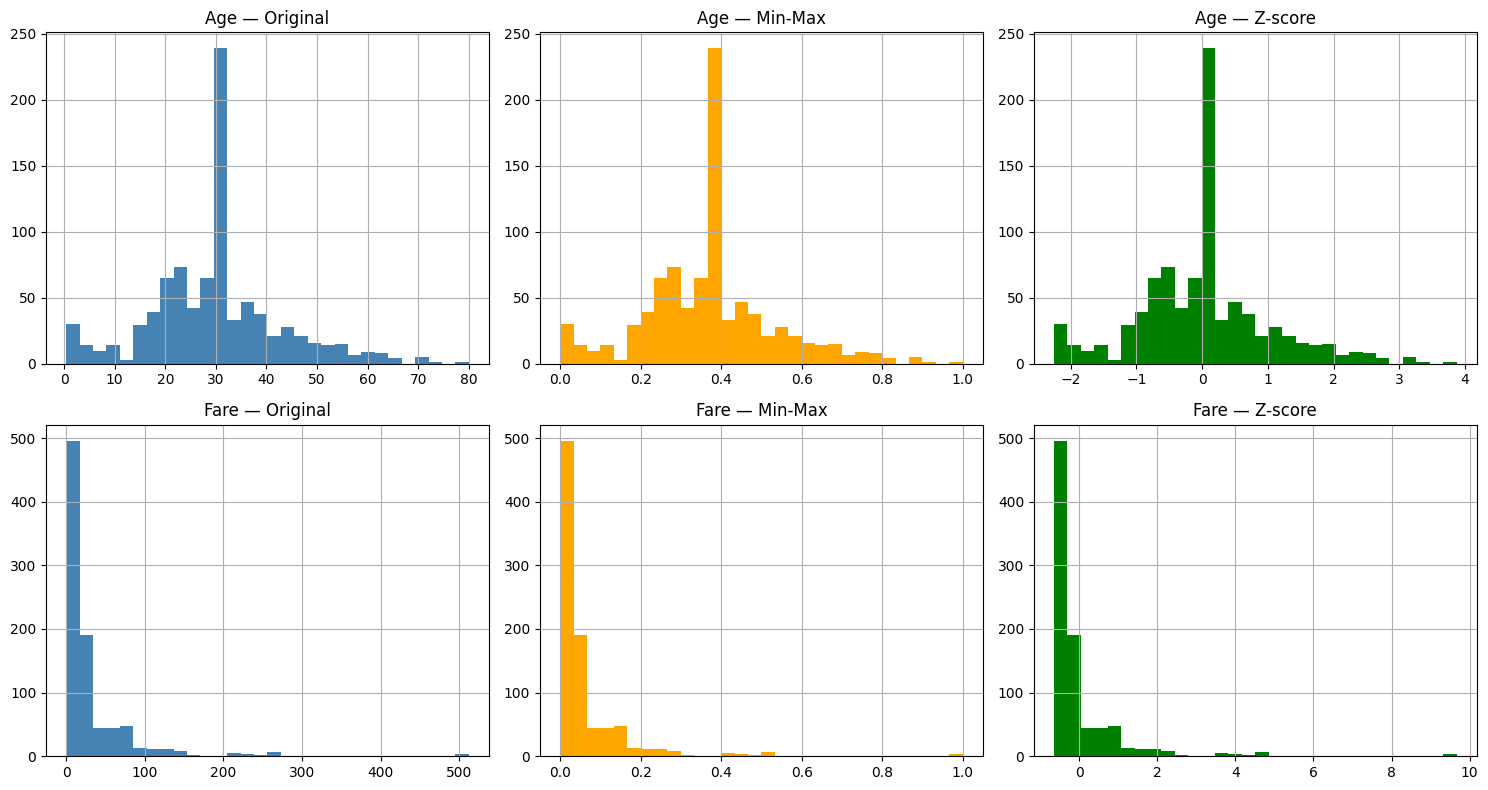

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Age
titanic_df["Age"].hist(ax=axes[0, 0], bins=30, color="steelblue")
axes[0, 0].set_title("Age — Original")

titanic_df["Age_MinMax"].hist(ax=axes[0, 1], bins=30, color="orange")
axes[0, 1].set_title("Age — Min-Max")

titanic_df["Age_Zscore"].hist(ax=axes[0, 2], bins=30, color="green")
axes[0, 2].set_title("Age — Z-score")

# Fare
titanic_df["Fare"].hist(ax=axes[1, 0], bins=30, color="steelblue")
axes[1, 0].set_title("Fare — Original")

titanic_df["Fare_MinMax"].hist(ax=axes[1, 1], bins=30, color="orange")
axes[1, 1].set_title("Fare — Min-Max")

titanic_df["Fare_Zscore"].hist(ax=axes[1, 2], bins=30, color="green")
axes[1, 2].set_title("Fare — Z-score")

plt.tight_layout()
plt.show()


### Normalizations Applied
| Column | Method | Result range |
|---|---|---|
| Age | Min-Max | [0.0, 1.0] |
| Age | Z-score | [-2.25, 3.87] |
| Fare | Min-Max | [0.0, 1.0] |
| Fare | Z-score | [-0.65, 9.67] |

### Distribution Analysis

**Age :**
- Original : range [0, 80], roughly bell-shaped.
- Min-Max : same shape, rescaled to [0, 1].
- Z-score : centered at 0, std=1 — shape unchanged.
- Both methods preserve the original distribution shape.

**Fare :**
- Original : highly right-skewed, most values near 0,
  extreme outliers up to 512.
- Min-Max : same skewed shape, compressed to [0, 1] —
  outliers push most values toward 0.
- Z-score : same skewed shape, centered at 0 —
  outliers visible up to 10.

### Conclusion
- Normalization **rescales** values but does NOT
  change the shape of the distribution.
- For skewed features like Fare, a log transformation
  should be applied before normalization
  to reduce the impact of outliers.

EXERCICE 4

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numerical columns for PCA
num_cols = ["Age", "Fare", "SibSp", "Parch", "FamilySize", "Pclass"]

# Scale first (PCA requires scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(titanic_df[num_cols])

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio :", pca.explained_variance_ratio_.round(3))
print("Total variance explained  :", pca.explained_variance_ratio_.sum().round(3))

Explained variance ratio : [0.429 0.281]
Total variance explained  : 0.71


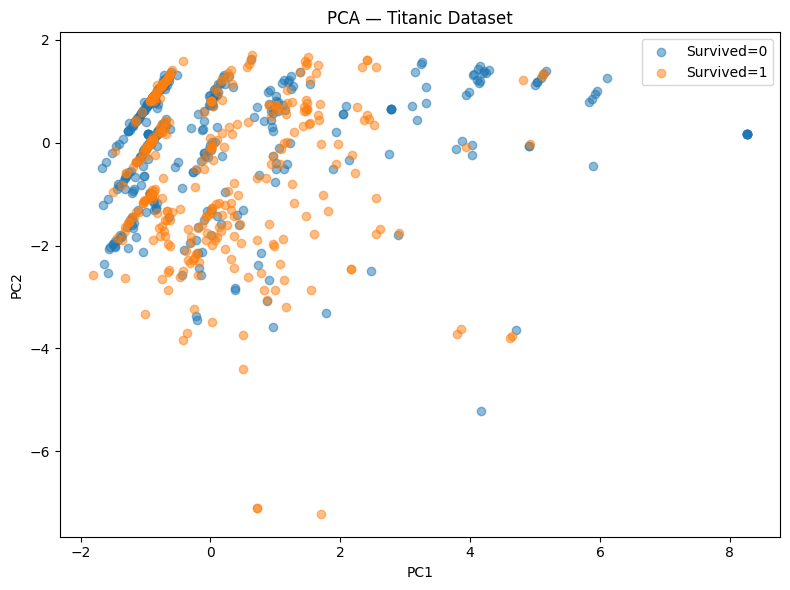

In [ ]:
# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Survived"] = titanic_df["Survived"].values

# Plot
plt.figure(figsize=(8, 6))
for label, group in pca_df.groupby("Survived"):
    plt.scatter(group["PC1"], group["PC2"],
                label=f"Survived={label}", alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — Titanic Dataset")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Aggregate by Pclass
agg_df = titanic_df.groupby("Pclass").agg(
    Survival_Rate=("Survived", "mean"),
    Avg_Age=("Age", "mean"),
    Avg_Fare=("Fare", "mean"),
    Total_Passengers=("PassengerId", "count")
).round(2)

print(agg_df)

        Survival_Rate  Avg_Age  Avg_Fare  Total_Passengers
Pclass                                                    
1                0.63    37.05     84.15               216
2                0.47    29.87     20.66               184
3                0.24    26.40     13.68               491


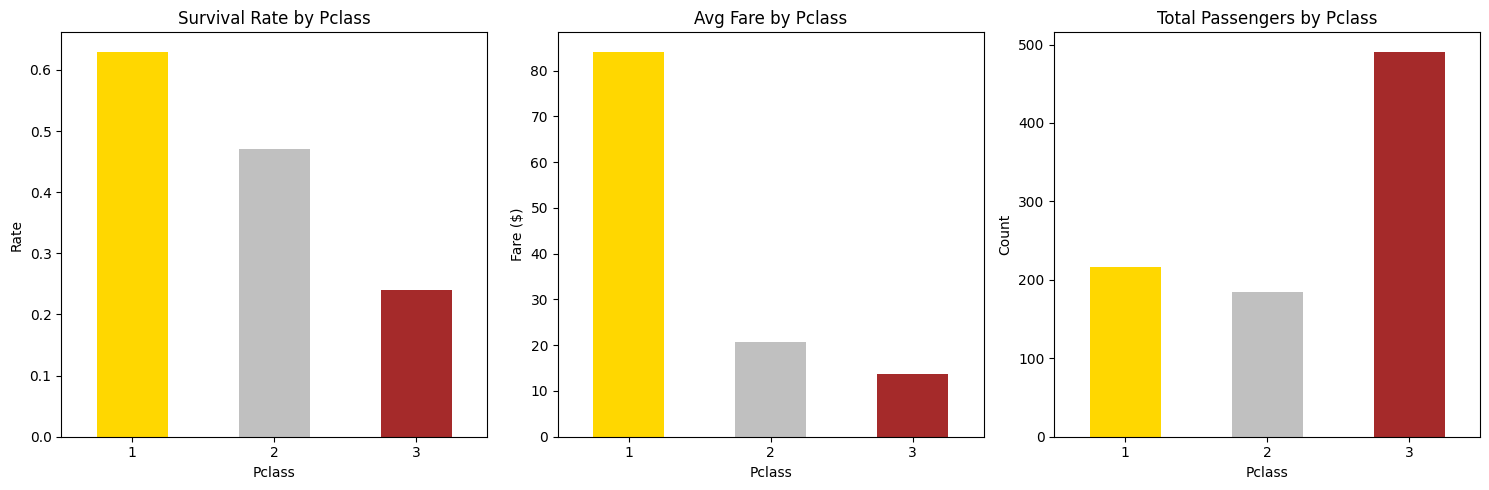

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Survival Rate by Pclass
agg_df["Survival_Rate"].plot(kind="bar", ax=axes[0],
                              color=["gold", "silver", "brown"],
                              title="Survival Rate by Pclass")
axes[0].set_ylabel("Rate")
axes[0].set_xticklabels([1, 2, 3], rotation=0)

# Avg Fare by Pclass
agg_df["Avg_Fare"].plot(kind="bar", ax=axes[1],
                         color=["gold", "silver", "brown"],
                         title="Avg Fare by Pclass")
axes[1].set_ylabel("Fare ($)")
axes[1].set_xticklabels([1, 2, 3], rotation=0)

# Total Passengers by Pclass
agg_df["Total_Passengers"].plot(kind="bar", ax=axes[2],
                                 color=["gold", "silver", "brown"],
                                 title="Total Passengers by Pclass")
axes[2].set_ylabel("Count")
axes[2].set_xticklabels([1, 2, 3], rotation=0)

plt.tight_layout()
plt.show()



### PCA — Dimensionality Reduction
| Component | Variance Explained |
|---|---|
| PC1 | 42.9% |
| PC2 | 28.1% |
| Total | 71.0% |

2 components capture 71% of the total variance in
6 numerical features (Age, Fare, SibSp, Parch, FamilySize, Pclass).
The PCA scatter plot shows partial separation between
survivors and non-survivors — some overlap remains,
suggesting other features are needed for full separation.

### Aggregation by Pclass
| Pclass | Survival Rate | Avg Age | Avg Fare | Passengers |
|---|---|---|---|---|
| 1 (First) | 63% | 37.05 | $84.15 | 216 |
| 2 (Second) | 47% | 29.87 | $20.66 | 184 |
| 3 (Third) | 24% | 26.40 | $13.68 | 491 |

### Key Insights
- First class passengers had the highest survival rate (63%)
  and paid the highest fares ($84 avg).
- Third class had the most passengers (491) but the lowest
  survival rate (24%) and cheapest fares ($13 avg).
- A clear correlation exists between passenger class,
  fare paid and survival rate.

EXERCICE  5

In [ ]:
import pandas as pd
import zipfile
import requests
import io
from sklearn.preprocessing import MinMaxScaler

def load_csv_from_zip_url(url):
    response = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
    return pd.read_csv(z.open(csv_name), encoding="latin-1")

url_superstore = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Superstore%20Sales%20Data.zip"

superstore_df = load_csv_from_zip_url(url_superstore)

# Min-Max normalization on Sales and Profit
scaler_mm = MinMaxScaler()
superstore_df["Sales_normalized"]  = scaler_mm.fit_transform(superstore_df[["Sales"]])
superstore_df["Profit_normalized"] = scaler_mm.fit_transform(superstore_df[["Profit"]])

print(superstore_df[["Sales", "Sales_normalized",
                      "Profit", "Profit_normalized"]].head())

print("\nSales_normalized stats :")
print(superstore_df["Sales_normalized"].describe().round(3))

print("\nProfit_normalized stats :")
print(superstore_df["Profit_normalized"].describe().round(3))

     Sales  Sales_normalized   Profit  Profit_normalized
0  408.300          0.018016  106.140           0.447076
1  120.366          0.005297   36.036           0.442402
2   66.120          0.002901   29.640           0.441976
3   44.865          0.001962  -26.055           0.438263
4  113.670          0.005002   37.770           0.442518

Sales_normalized stats :
count    51290.000
mean         0.011
std          0.022
min          0.000
25%          0.001
50%          0.004
75%          0.011
max          1.000
Name: Sales_normalized, dtype: float64

Profit_normalized stats :
count    51290.000
mean         0.442
std          0.012
min          0.000
25%          0.440
50%          0.441
75%          0.442
max          1.000
Name: Profit_normalized, dtype: float64



### Min-Max Normalization Applied
| Column | Original Range | Normalized Range |
|---|---|---|
| Sales | 0 → max | 0.000 → 1.000 |
| Profit | negative → max | 0.000 → 1.000 |

### Results
| Metric | Sales_normalized | Profit_normalized |
|---|---|---|
| Mean | 0.011 | 0.442 |
| Std | 0.022 | 0.012 |
| Min | 0.000 | 0.000 |
| Max | 1.000 | 1.000 |

### Key Observations
- Sales_normalized has a very low mean (0.011) — most sales
  values are small, with a few very large outliers pulling
  the max to 1.0.
- Profit_normalized is centered around 0.442 — meaning
  the dataset contains both negative profits (losses)
  and positive profits, with 0 representing the minimum loss.
- Min-Max normalization preserves the relative distribution
  while bounding all values between 0 and 1.

EXERCICE 6

In [ ]:
url_air = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Air%20Quality%20Data%20in%20India.zip"

air_df = load_csv_from_zip_url(url_air)

print(air_df.columns.tolist())
print(air_df.head())

['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [ ]:
# Convert Date to datetime
air_df["Date"] = pd.to_datetime(air_df["Date"])

# Extract Month and Year
air_df["Month"] = air_df["Date"].dt.to_period("M")

# Group by City and Month, calculate average of key measurements
agg_air = air_df.groupby(["City", "Month"])[["PM2.5", "PM10", "NO2"]].mean().round(2)

print(agg_air.head(10))
print(f"\nShape : {agg_air.shape}")

                    PM2.5  PM10    NO2
City      Month                       
Ahmedabad 2015-01   82.68   NaN  26.85
          2015-02  116.10   NaN  31.32
          2015-03  110.47   NaN  27.94
          2015-04  101.68   NaN  20.75
          2015-05   74.92   NaN  17.33
          2015-06   48.97   NaN  13.89
          2015-07   52.42   NaN   7.50
          2015-08   40.88   NaN  17.39
          2015-09   42.31   NaN  15.82
          2015-10  109.77   NaN  31.42

Shape : (1005, 3)


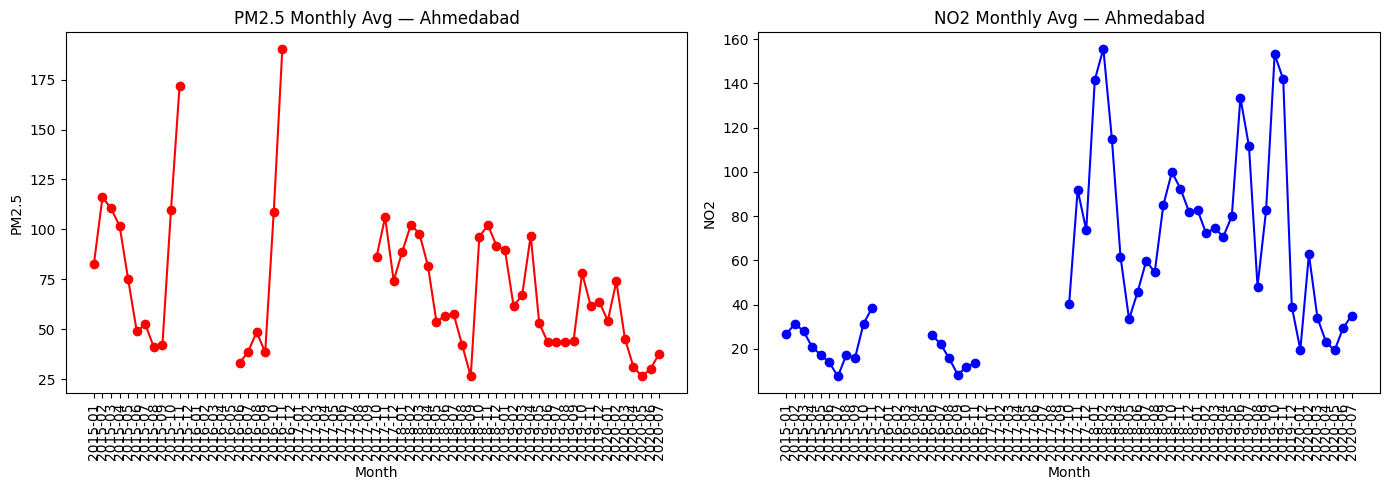

In [ ]:
# Filter one city for visualization
city = "Ahmedabad"
city_df = agg_air.loc[city].reset_index()
city_df["Month"] = city_df["Month"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PM2.5 trend
axes[0].plot(city_df["Month"], city_df["PM2.5"], marker="o", color="red")
axes[0].set_title(f"PM2.5 Monthly Avg — {city}")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("PM2.5")
axes[0].tick_params(axis="x", rotation=90)

# NO2 trend
axes[1].plot(city_df["Month"], city_df["NO2"], marker="o", color="blue")
axes[1].set_title(f"NO2 Monthly Avg — {city}")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("NO2")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


### Dataset Overview
- 16 columns : City, Date, PM2.5, PM10, NO2, NOx, NH3,
  CO, SO2, O3, Benzene, Toluene, Xylene, AQI, AQI_Bucket
- Date converted to datetime and grouped by Month.
- Aggregated shape : 1005 rows (city x month combinations).

### Key Measurements Aggregated
| Column | Description |
|---|---|
| PM2.5 | Fine particulate matter — main air quality indicator |
| PM10 | Coarse particulate matter — NaN for some cities |
| NO2 | Nitrogen dioxide — traffic and industrial emissions |

### Trends Observed — Ahmedabad
**PM2.5 :**
- High values in winter months (Oct-Feb) — up to 190.
- Lower values in summer months (Jun-Aug) — down to 25.
- Seasonal pattern linked to weather and wind conditions.

**NO2 :**
- Sharp increase from 2019 onwards — up to 155.
- Volatile month-to-month fluctuations.
- Likely linked to increased industrial and traffic activity.

### Conclusion
Grouping by City and Month reveals clear seasonal patterns
in air quality. Winter months consistently show higher
pollution levels across both PM2.5 and NO2 indicators.